# Proyecto 5: Vision Transformer desde Imagen a Tokens

**Curso:** CC-0C2 Procesamiento del Lenguaje Natural

**Tema Central:** Entender cómo una imagen se transforma en una secuencia de patches y cómo un Transformer puede clasificarla.

## Sección 1: Importaciones y Setup

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, Subset
import torchvision
import torchvision.transforms as transforms
from collections import Counter

import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import math
from pathlib import Path
from collections import OrderedDict
from tqdm import tqdm
import seaborn as sns
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo utilizado: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Capability: {torch.cuda.get_device_capability(0)}")

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Dispositivo utilizado: cuda
GPU: NVIDIA GeForce RTX 3060
CUDA Capability: (8, 6)


In [20]:
# Configuración de hiperparámetros
class ViTConfig:
    # Parámetros de imagen y patches
    image_size = 32               # Tamaño de imagen de entrada: 32x32
    patch_size = 4                # Tamaño de cada patch: 4x4
    num_patches = (image_size // patch_size) ** 2  # (32/4)^2 = 64 patches
    patch_dim = patch_size ** 2 * 3  # 4*4*3 = 48 (tres canales RGB)
    
    # Parámetros del modelo
    embed_dim = 192                # Dimensión de embeddings
    num_heads = 6                 # Número de cabeceras de atención
    num_layers = 12                # Número de bloques transformer
    mlp_dim = 768                 # Dimensión interna de MLP (4x embed_dim)
    dropout = 0.1                  # Tasa de dropout
    attention_dropout = 0.0        # Dropout en atención
    
    # Parámetros de entrenamiento
    num_classes = 3
    batch_size = 128
    num_epochs = 20
    learning_rate = 1e-3
    weight_decay = 0.05
    warmup_epochs = 5
    
    # Para ablación
    use_class_token = True         # Usar token [class]
    use_pos_encoding = True        # Usar codificación posicional
    pooling_method = 'class'       # 'class' o 'mean'
    
config = ViTConfig()

print(f"Configuración ViT:")
print(f"  Tamaño imagen: {config.image_size}×{config.image_size}")
print(f"  Tamaño patch: {config.patch_size}×{config.patch_size}")
print(f"  Número de patches: {config.num_patches}")
print(f"  Dimensión patch (aplanado): {config.patch_dim}")
print(f"  Dimensión embedding: {config.embed_dim}")
print(f"  Cabeceras atención: {config.num_heads}")
print(f"  Capas transformer: {config.num_layers}")
print(f"  MLP dimensión: {config.mlp_dim}")

Configuración ViT:
  Tamaño imagen: 32×32
  Tamaño patch: 4×4
  Número de patches: 64
  Dimensión patch (aplanado): 48
  Dimensión embedding: 192
  Cabeceras atención: 6
  Capas transformer: 12
  MLP dimensión: 768


## Sección 2: Image Patching - Conversión de Imagen a Secuencia

### Idea Principal

Una imagen $I$ de tamaño $H \times W \times C$ se divide en $N = \left(\frac{H}{P}\right) \times \left(\frac{W}{P}\right)$ patches no superpuestos de tamaño $P \times P \times C$.

**Ejemplo:** 
- Imagen: $32 \times 32 \times 3$ (RGB)
- Patch size: $4 \times 4$
- Número de patches: $(32/4)^2 = 64$ patches
- Cada patch: $4\times 4 \times 3 = 48$ elementos

Luego cada patch se **aplana** (flatten) en un vector de longitud 48.

In [21]:
# Función para extraer patches de una imagen
def extract_patches(image, patch_size):
    """
    Extrae patches no superpuestos de una imagen.
    
    Args:
        image: tensor de forma (C, H, W) o (B, C, H, W)
        patch_size: tamaño del patch (int)
    
    Returns:
        patches: tensor de patches aplanados
    """
    # Si es imagen única, agregar dimensión batch
    if image.dim() == 3:
        image = image.unsqueeze(0)  # (B=1, C, H, W)
    
    B, C, H, W = image.shape
    
    # Usar unfold para extraer patches
    # unfold(dimension, size, step)
    patches = image.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    # (B, C, H/patch_size, W/patch_size, patch_size, patch_size)
    
    patches = patches.contiguous().view(B, C, (H // patch_size), (W // patch_size), -1)
    # (B, C, num_patch_h, num_patch_w, patch_area)
    
    patches = patches.permute(0, 2, 3, 1, 4).contiguous()
    # (B, num_patch_h, num_patch_w, C, patch_area)
    
    patches = patches.view(B, (H // patch_size) * (W // patch_size), C * patch_size * patch_size)
    # (B, num_patches, patch_dim)
    
    return patches

# Demostración con una imagen CIFAR-10
print("Descargando CIFAR-10...")
cifar_transform = transforms.Compose([
    transforms.ToTensor(),
])
cifar_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=cifar_transform)
print(f"\n{'='*60}")
print("\nDemostrando extracción de patches...")
demo_image, _ = cifar_data[0]
patch_size_demo = 4

patches_demo = extract_patches(demo_image, patch_size_demo)
print(f"Imagen original: {demo_image.shape}")
print(f"Patches extraídos: {patches_demo.shape}")
print(f"  Número de patches: {patches_demo.shape[1]}")
print(f"  Dimensión cada patch (aplanado): {patches_demo.shape[2]}")

Descargando CIFAR-10...
Files already downloaded and verified


Demostrando extracción de patches...
Imagen original: torch.Size([3, 32, 32])
Patches extraídos: torch.Size([1, 64, 48])
  Número de patches: 64
  Dimensión cada patch (aplanado): 48


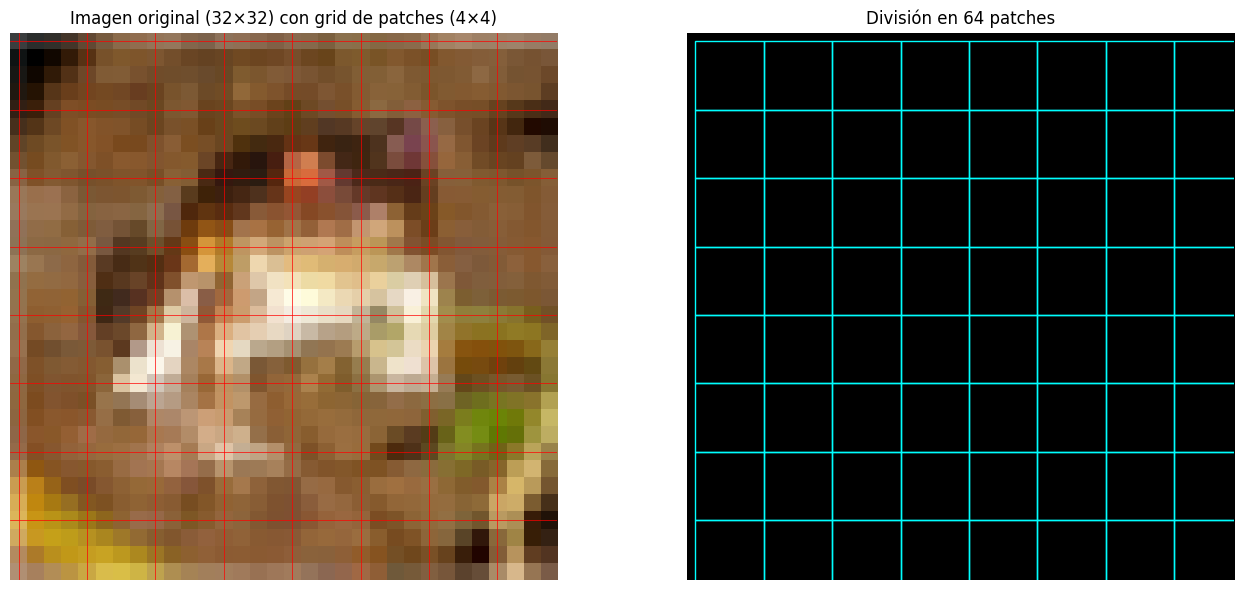

In [22]:
def visualize_patches(image, patch_size, title="Extracción de Patches"):
    """Visualiza cómo se divide una imagen en patches"""
    C, H, W = image.shape
    num_patch_h = H // patch_size
    num_patch_w = W // patch_size
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Imagen original
    img_rgb = image.permute(1, 2, 0).numpy()
    img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min() + 1e-5)
    axes[0].imshow(img_rgb)
    
    # Dibujar grid de patches
    for i in range(num_patch_h):
        axes[0].axhline(y=i*patch_size, color='red', linewidth=0.5)
    for j in range(num_patch_w):
        axes[0].axvline(x=j*patch_size, color='red', linewidth=0.5)
    axes[0].set_title(f"Imagen original ({H}×{W}) con grid de patches ({patch_size}×{patch_size})")
    axes[0].axis('off')
    
    patches = extract_patches(image, patch_size)  # (1, num_patches, patch_dim)
    patches = patches[0]  # (num_patches, patch_dim)
    
    patch_grid_shape = (num_patch_h, num_patch_w, patch_size, patch_size, C)
    patches_reshaped = patches.view(*patch_grid_shape)
    
    # Mostrar la grilla de patches
    axes[1].imshow(np.zeros((H, W, 3)), cmap='gray')
    axes[1].set_title(f"División en {num_patch_h*num_patch_w} patches")
    for i in range(num_patch_h):
        for j in range(num_patch_w):
            axes[1].add_patch(plt.Rectangle((j*patch_size, i*patch_size), 
                                            patch_size, patch_size, 
                                            fill=False, edgecolor='cyan', linewidth=1))
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_patches(demo_image, patch_size=4, title="Ejemplo: CIFAR-10 con patches de 4×4")

## Sección 3: Patch Embedding y Proyección Lineal

Una vez que tenemos los patches **aplanados**, necesitamos proyectarlos al espacio de embeddings del modelo.

### Flujo:
1. Patch original: $4 \times 4 \times 3$
2. Patch aplanado: $\mathbb{R}^{P^2 \cdot C}$ (ej: 48)
3. Proyección lineal: $\mathbb{R}^{d_{model}}$ (ej: 192)
4. Embedding resultado: vector aprendible que representa al patch


Esto se implementa con una simple capa lineal: $E_{patch} = \text{Linear}(patch_{flat})$

In [23]:
class PatchEmbedding(nn.Module):
    """
    Convierte una imagen en patches y los proyecta a embeddings.
    
    Arquitectura:
        Imagen (H×W×C) → Patches (N, P²C) → Embeddings (N, d_model)
    """
    
    def __init__(self, 
                 image_size: int,
                 patch_size: int,
                 in_channels: int,
                 embed_dim: int):
        super().__init__()
        
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = (patch_size ** 2) * in_channels
        
        # Capa lineal que proyecta patches aplanados a embeddings
        self.proj = nn.Linear(self.patch_dim, embed_dim)
        
    def forward(self, x):
        """
        Args:
            x: (B, C, H, W)
        Returns:
            patches_embed: (B, num_patches, embed_dim)
        """
        B, C, H, W = x.shape
        
        # Extraer patches
        patches = extract_patches(x, self.patch_size)  # (B, num_patches, patch_dim)
        
        # Proyectar a embeddings
        patch_embed = self.proj(patches)  # (B, num_patches, embed_dim)
        
        return patch_embed

# Demostración
patch_embedding = PatchEmbedding(
    image_size=config.image_size,
    patch_size=config.patch_size,
    in_channels=3,
    embed_dim=config.embed_dim
).to(device)

input_tensor = demo_image.unsqueeze(0).to(device)

output = patch_embedding(input_tensor)

print(f"Input shape: {input_tensor.shape}") # (1, 3, 32, 32)
print(f"Output patch embeddings shape: {output.shape}")
print(f"  Batch size: {output.shape[0]}")
print(f"  Número de patches: {output.shape[1]}")
print(f"  Dimensión embedding: {output.shape[2]}")
print(f"\nParámetros de PatchEmbedding: {sum(p.numel() for p in patch_embedding.parameters()):,}")

Input shape: torch.Size([1, 3, 32, 32])
Output patch embeddings shape: torch.Size([1, 64, 192])
  Batch size: 1
  Número de patches: 64
  Dimensión embedding: 192

Parámetros de PatchEmbedding: 9,408


## Sección 4: Token [class] y Codificación Posicional

### Token [class]

Agregamos un **token especial** al inicio de la secuencia de patches:

$$\mathbf{z}_0 = [\text{token\_class}]$$

Este token se procesa a través del transformer y su salida final se usa para la predicción de clase.

**Propósito:**
- Agregar información global de la imagen
- Facilitar la tarea de clasificación
- Comparable a hacer un "pooling contextual"

### Codificación Posicional

Cada patch necesita información sobre su **posición espacial** en la imagen original. Usamos **codificación sinusoidal**:

$$PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Esto se suma al embedding: $E_{final} = E_{patch} + PE(pos)$

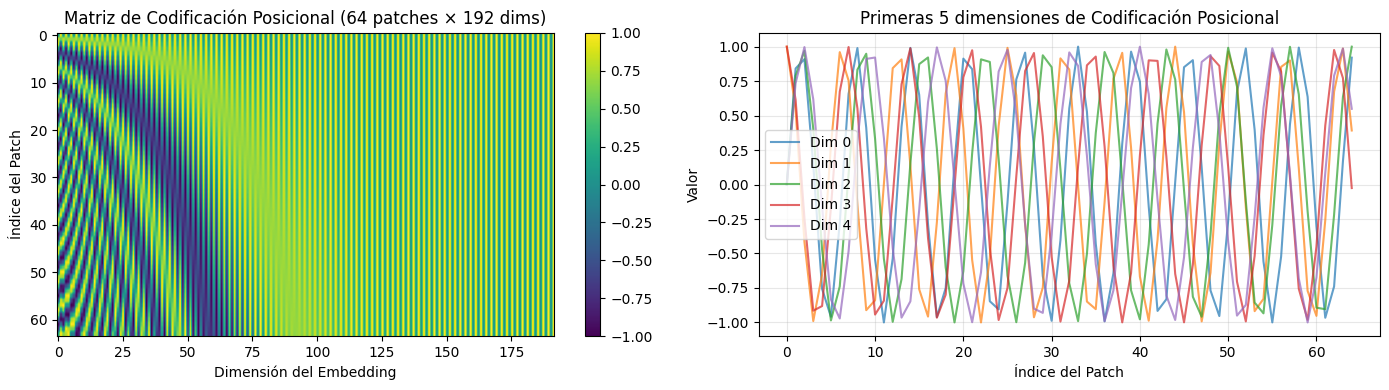

In [24]:
class PositionalEncoding(nn.Module):
    """
    Codificación posicional sinusoidal para patches.
    
    Añade información de posición espacial a cada patch para que el modelo
    sepa dónde está cada parche en la imagen original.
    """
    
    def __init__(self, embed_dim: int, max_seq_len: int = 1000, dropout: float = 0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.dropout = nn.Dropout(p=dropout)
        
        # Crear matriz de posiciones (max_seq_len, embed_dim)
        pe = torch.zeros(max_seq_len, embed_dim)
        # Se genera números 0,1,2,...,64 los cuales representan la posición de un patch
        position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)
        
        # Divisor para la fórmula sinusoidal
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * 
                            (-math.log(10000.0) / embed_dim))
        
        # Aplicar sin y cos alternados
        pe[:, 0::2] = torch.sin(position * div_term)
        if embed_dim % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        
        # Registrar buffer (no es parámetro entrenable)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_seq_len, embed_dim)
    
    def forward(self, x):
        """
        Args:
            x: (B, seq_len, embed_dim)
        Returns:
            x + positional_encoding
        """
        seq_len = x.shape[1]
        pos_enc = self.pe[:, :seq_len, :].to(x.device)
        x = x + pos_enc
        return self.dropout(x)

# Visualizar patrón de codificación posicional
pos_enc = PositionalEncoding(embed_dim=config.embed_dim, max_seq_len=65)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Mostrar matriz completa
pe_matrix = pos_enc.pe[0, :64, :]  # Primeros 64 patches
im1 = axes[0].imshow(pe_matrix.cpu().numpy(), cmap='viridis', aspect='auto')
axes[0].set_title('Matriz de Codificación Posicional (64 patches × 192 dims)')
axes[0].set_xlabel('Dimensión del Embedding')
axes[0].set_ylabel('Índice del Patch')
plt.colorbar(im1, ax=axes[0])

# Mostrar algunos patrones dimensionales
pos_enc_plot = pos_enc.pe[0, :200, :5].cpu().numpy()
for i in range(5):
    axes[1].plot(pos_enc_plot[:, i], label=f'Dim {i}', alpha=0.7)
axes[1].set_title('Primeras 5 dimensiones de Codificación Posicional')
axes[1].set_xlabel('Índice del Patch')
axes[1].set_ylabel('Valor')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# Demostración: cómo agregar el token [class] a la secuencia
def add_class_token(patch_embeddings, embed_dim, batch_size, device):
    """
    Agrega el token [class] al inicio de la secuencia de patches.
    
    Args:
        patch_embeddings: (B, num_patches, embed_dim)
        embed_dim: dimensión del embedding
        batch_size: tamaño del batch
        device: dispositivo (CPU/GPU)
    
    Returns:
        sequence_with_class: (B, num_patches+1, embed_dim)
    """
    # Token [class] es un parámetro aprendible único para todo el batch
    class_token = torch.randn(1, 1, embed_dim).to(device)
    
    # Expandir para cada elemento del batch
    class_token_expanded = class_token.expand(batch_size, 1, embed_dim)
    
    # Concatenar al inicio
    sequence_with_class = torch.cat([class_token_expanded, patch_embeddings], dim=1)
    
    return sequence_with_class, class_token

# Demostración
input_tensor = demo_image.unsqueeze(0).to(device)
patch_embeddings = patch_embedding(input_tensor)
seq_with_class, cls_token = add_class_token(patch_embeddings, config.embed_dim, patch_embeddings.shape[0], device)

print(f"Patches originales: {patch_embeddings.shape}")
print(f"Secuencia con [class] token: {seq_with_class.shape}")
print(f"  Token [class] forma: {cls_token.shape}")
print(f"\nNota: El token [class] se agregó al índice 0")
print(f"Ahora tenemos {seq_with_class.shape[1]} elementos en la secuencia")

Patches originales: torch.Size([1, 64, 192])
Secuencia con [class] token: torch.Size([1, 65, 192])
  Token [class] forma: torch.Size([1, 1, 192])

Nota: El token [class] se agregó al índice 0
Ahora tenemos 65 elementos en la secuencia


## Sección 5: Multi-Head Self-Attention para Visión

Self-attention permite que cada patch **mire** a todos los otros patches y determine su relevancia.

### Scaled Dot-Product Attention

Para cada patch (query), calculamos:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Donde:
- $Q$ = queries (¿a qué atienden?)
- $K$ = keys (¿qué puedes atender?)
- $V$ = values (¿qué información se transfiere?)
- $\sqrt{d_k}$ = escalamiento para estabilidad numérica

### Multi-Head Attention

En lugar de una cabecera, usamos múltiples: 

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)W^O$$

Cada cabecera aprende patrones de atención diferentes.

In [27]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Self-Attention para Vision Transformers.
    
    Permite que patches se atienten mutuamente, con múltiples cabeceras
    aprendiendo diferentes tipos de atención simultáneamente.
    """
    
    def __init__(self, embed_dim: int, num_heads: int, attn_drop: float = 0.0):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim debe ser divisible por num_heads"
        
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5
        
        # Proyecciones: Q, K, V en una sola operación
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(attn_drop)
    
    def forward(self, x, return_attention_weights=False):
        """
        Args:
            x: (B, seq_len, embed_dim) - secuencia de embeddings (patches + [class])
            return_attention_weights: si True, retorna las matrices de atención
        
        Returns:
            out: (B, seq_len, embed_dim) - secuencia procesada por atención
            attn_weights: (B, num_heads, seq_len, seq_len) - si return_attention_weights=True
        """
        B, N, C = x.shape  # (batch, seq_len, embed_dim)
        
        # Proyectar Q, K, V
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, num_heads, seq_len, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        # Calcular scores: Q @ K^T / sqrt(d_k)
        scores = (q @ k.transpose(-2, -1)) * self.scale  # (B, num_heads, seq_len, seq_len)
        
        # Aplicar softmax para obtener pesos de atención
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.attn_drop(attn_weights)
        
        # Aplicar atención a values
        out = attn_weights @ v  # (B, num_heads, seq_len, head_dim)
        
        # Concatenar cabeceras
        out = out.transpose(1, 2).reshape(B, N, C)  # (B, seq_len, embed_dim)
        
        # Proyección final
        out = self.proj(out)
        out = self.proj_drop(out)
        
        if return_attention_weights:
            return out, attn_weights
        return out

# Demostración
mha = MultiHeadAttention(embed_dim=config.embed_dim, num_heads=config.num_heads).to(device)

# Input: secuencia de patches
input_tensor = demo_image.unsqueeze(0).to(device)
patch_embeddings = patch_embedding(input_tensor)
seq_with_class, cls_token = add_class_token(patch_embeddings, config.embed_dim, patch_embeddings.shape[0], device)
output_mha, attn_weights = mha(seq_with_class, return_attention_weights=True)

print(f"Input shape: {seq_with_class.shape}")
print(f"Output shape: {output_mha.shape}")
print(f"Attention weights shape: {attn_weights.shape}")
print(f"  (batch={attn_weights.shape[0]}, heads={attn_weights.shape[1]}, seq_len={attn_weights.shape[2]}×{attn_weights.shape[3]})")
print(f"\nParámetros MultiHeadAttention: {sum(p.numel() for p in mha.parameters()):,}")

Input shape: torch.Size([1, 65, 192])
Output shape: torch.Size([1, 65, 192])
Attention weights shape: torch.Size([1, 6, 65, 65])
  (batch=1, heads=6, seq_len=65×65)

Parámetros MultiHeadAttention: 148,224


## Sección 6: Transformer Block - Add & Norm + FFN

Cada bloque transformer contiene:

1. **LayerNorm** → normaliza activaciones
2. **MultiHeadAttention** → auto-atención
3. **Residual Connection** → suma la entrada original (skip connection)
4. **LayerNorm** → normaliza nuevamente
5. **FeedForward (MLP)** → red neuronal posicional
6. **Residual Connection** → suma entrada

**Pre-Norm Architecture:**
$$x' = x + \text{MultiHeadAttention}(\text{LayerNorm}(x))$$
$$x'' = x' + \text{MLP}(\text{LayerNorm}(x'))$$

In [29]:
class TransformerBlock(nn.Module):
    """
    Bloque Transformer con Pre-Norm architecture.
    
    Flujo: x → LayerNorm → MHA → Residual → LayerNorm → MLP → Residual → output
    """
    
    def __init__(self, embed_dim: int, num_heads: int, mlp_dim: int, dropout: float = 0.1):
        super().__init__()
        
        self.norm1 = nn.LayerNorm(embed_dim)
        self.mha = MultiHeadAttention(embed_dim, num_heads, attn_drop=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        
        # FeedForward Network
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        """
        Args:
            x: (B, seq_len, embed_dim)
        
        Returns:
            out: (B, seq_len, embed_dim)
        """
        # Pre-Norm MHA branch
        x = x + self.mha(self.norm1(x))
        
        # Pre-Norm MLP branch
        x = x + self.mlp(self.norm2(x))
        
        return x

# Demostración
block = TransformerBlock(embed_dim=config.embed_dim, 
                         num_heads=config.num_heads, 
                         mlp_dim=config.mlp_dim).to(device)

input_tensor = demo_image.unsqueeze(0).to(device)
patch_embeddings = patch_embedding(input_tensor)
seq_with_class, cls_token = add_class_token(patch_embeddings, config.embed_dim, patch_embeddings.shape[0], device)

output_block = block(seq_with_class)

print(f"Input: {seq_with_class.shape}")
print(f"Output: {output_block.shape}")
print(f"Parámetros TransformerBlock: {sum(p.numel() for p in block.parameters()):,}")

Input: torch.Size([1, 65, 192])
Output: torch.Size([1, 65, 192])
Parámetros TransformerBlock: 444,864


## Sección 7: Arquitectura Completa Vision Transformer

Ensamblamos todos los componentes:

```
Imagen (H×W×3)
    ↓
Patch Embedding (N, embed_dim)
    ↓
+ [class] token + Positional Encoding
    ↓
Stack de Transformer Blocks (N times)
    ↓
LayerNorm del [class] token
    ↓
Classification Head (MLP)
    ↓
Logits (num_classes)
```

In [30]:
class VisionTransformer(nn.Module):
    """
    Vision Transformer (ViT) completo para clasificación de imágenes.
    
    Implementa el flujo: Imagen → Patches → Embeddings → Transformer → Clasificación
    """
    
    def __init__(self, config: ViTConfig):
        super().__init__()
        self.config = config
        
        # 1. Patch Embedding
        self.patch_embed = PatchEmbedding(
            image_size=config.image_size,
            patch_size=config.patch_size,
            in_channels=3,
            embed_dim=config.embed_dim
        )
        
        # 2. Token [class] (parámetro aprendible)
        self.class_token = nn.Parameter(torch.zeros(1, 1, config.embed_dim))
        
        # 3. Codificación posicional
        self.pos_encoding = PositionalEncoding(
            embed_dim=config.embed_dim,
            max_seq_len=config.num_patches + 1,  # +1 por [class]
            dropout=config.dropout
        )
        
        # 4. Stack de bloques transformer
        self.transformer = nn.Sequential(
            *[TransformerBlock(config.embed_dim, config.num_heads, 
                             config.mlp_dim, config.dropout) 
              for _ in range(config.num_layers)]
        )
        
        # 5. LayerNorm final
        self.norm = nn.LayerNorm(config.embed_dim)
        
        # 6. Cabecera de clasificación
        self.head = nn.Linear(config.embed_dim, config.num_classes)
        
        # Inicialización
        nn.init.trunc_normal_(self.class_token, std=0.02)
        self._init_weights()
    
    def _init_weights(self):
        """Inicialización de pesos típica para ViT"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LayerNorm):
                nn.init.constant_(m.bias, 0)
                nn.init.constant_(m.weight, 1.0)
    
    def forward(self, x):
        """
        Args:
            x: (B, 3, 32, 32) - imagen
        
        Returns:
            logits: (B, num_classes) - predicciones
        """
        B = x.shape[0]
        
        # 1. Patch embedding
        patch_embed = self.patch_embed(x)  # (B, num_patches, embed_dim)
        
        # 2. Agregar [class] token
        class_token = self.class_token.expand(B, -1, -1)  # (B, 1, embed_dim)
        x = torch.cat([class_token, patch_embed], dim=1)  # (B, num_patches+1, embed_dim)
        
        # 3. Agregar posición
        x = self.pos_encoding(x)  # (B, num_patches+1, embed_dim)
        
        # 4. Transformer blocks
        x = self.transformer(x)  # (B, num_patches+1, embed_dim)
        
        # 5. LayerNorm
        x = self.norm(x)  # (B, num_patches+1, embed_dim)
        
        # 6. Tomar solo el [class] token para clasificación
        x = x[:, 0]  # (B, embed_dim)
        
        # 7. Cabecera de clasificación
        logits = self.head(x)  # (B, num_classes)
        
        return logits

# Crear modelo
vit_model = VisionTransformer(config).to(device)

# Mostrar resumen
print(f"\n{'='*60}")
print(f"Vision Transformer Model Summary")
print(f"{'='*60}")
print(f"\nTotal parameters: {sum(p.numel() for p in vit_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in vit_model.parameters() if p.requires_grad):,}")

# Demostración con imagen 
x_demo = demo_image.unsqueeze(0).to(device)
with torch.no_grad():
    logits = vit_model(x_demo)

print(f"\nInput shape: {x_demo.shape}")
print(f"Output shape: {logits.shape}")


Vision Transformer Model Summary

Total parameters: 5,348,931
Trainable parameters: 5,348,931

Input shape: torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 3])


## Sección 8: Preparación de Dataset y DataLoader

Usaremos **CIFAR-10**: 60,000 imágenes de 32×32 en 10 categorías.



In [54]:
selected_classes = ['airplane', 'automobile', 'bird']
# Índices reales en CIFAR-10
selected_class_ids = [0, 1, 2]

train_transform = transforms.Compose([
    transforms.Resize((config.image_size, config.image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1)
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((config.image_size, config.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

# Descargar CIFAR-10
print("\nDescargando CIFAR-10...")
full_train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)
full_test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

train_filtered_indices = []
test_filtered_indices = []
for idx, label in enumerate(full_train_dataset.targets):

    if label in selected_class_ids:
        train_filtered_indices.append(idx)

for idx, label in enumerate(full_test_dataset.targets):

    if label in selected_class_ids:
        test_filtered_indices.append(idx)

# 70% entrenamiento, 15% validación, 15% test
train_size = 700
val_size = 150
test_size = 150
random.seed(42)

random.shuffle(train_filtered_indices)
random.shuffle(test_filtered_indices)

train_indices = train_filtered_indices[:train_size]
val_indices = train_filtered_indices[
    train_size:train_size + val_size
]
test_indices = test_filtered_indices[:test_size]

train_subset = Subset(full_train_dataset, train_indices)

val_subset = Subset(full_train_dataset, val_indices)

test_subset = Subset(full_test_dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=config.batch_size, shuffle=True, num_workers=0)

val_loader = DataLoader(val_subset, batch_size=config.batch_size, shuffle=False, num_workers=0)

test_loader = DataLoader(test_subset, batch_size=config.batch_size, shuffle=False, num_workers=0)

cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
def count_classes(dataset_subset, dataset_name):
    labels = []
    for _, label in dataset_subset:
        labels.append(label)
    class_counts = Counter(labels)
    print(f"\n{dataset_name}")
    print("-" * 40)
    total = 0
    for class_id in selected_class_ids:
        class_name = cifar10_classes[class_id]
        count = class_counts[class_id]
        total += count
        print(f"{class_name:<15}: {count}")
    print("-" * 40)
    print(f"Total           : {total}")

# --- Al inicio del script ---
print(f"{'='*60}")
print(f"{'PREPARACIÓN DEL DATASET CIFAR-10':^60}")
print(f"{'='*60}")

# --- Durante la descarga y filtrado ---
print(f"\n[1/3] Configurando Clases...")
print(f"    > Seleccionadas: {', '.join(selected_classes)}")
print(f"    > IDs Reales:    {selected_class_ids}")

print(f"\n[2/3] Descargando y Filtrando...")
# (Aquí van las funciones de descarga de torchvision)
print(f"    > Imágenes encontradas (Train): {len(train_filtered_indices)}")
print(f"    > Imágenes encontradas (Test):  {len(test_filtered_indices)}")

# --- Resumen Final Consolidado ---
print(f"\n[3/3] Resumen del Dataset Final")
print(f"{'-'*60}")

# Tabla de Distribución de Muestras
print(f"{'Split':<15} | {'Imágenes':<10} | {'Batches':<10}")
print(f"{'-'*45}")
print(f"{'Entrenamiento':<15} | {len(train_subset):<10} | {len(train_loader):<10}")
print(f"{'Validación':<15} | {len(val_subset):<10} | {len(val_loader):<10}")
print(f"{'Test':<15} | {len(test_subset):<10} | {len(test_loader):<10}")

print(f"\nParámetros de entrada:")
print(f"    > Batch Size: {config.batch_size}")
print(f"    > Image Size: {config.image_size}x{config.image_size}")

# Distribución detallada por clase
print(f"\nDistribución Detallada por Clase:")
count_classes(train_subset, "DISTRIBUCIÓN: ENTRENAMIENTO")
count_classes(val_subset, "DISTRIBUCIÓN: VALIDACIÓN")
count_classes(test_subset, "DISTRIBUCIÓN: TEST")



Descargando CIFAR-10...
Files already downloaded and verified
Files already downloaded and verified
              PREPARACIÓN DEL DATASET CIFAR-10              

[1/3] Configurando Clases...
    > Seleccionadas: airplane, automobile, bird
    > IDs Reales:    [0, 1, 2]

[2/3] Descargando y Filtrando...
    > Imágenes encontradas (Train): 15000
    > Imágenes encontradas (Test):  3000

[3/3] Resumen del Dataset Final
------------------------------------------------------------
Split           | Imágenes   | Batches   
---------------------------------------------
Entrenamiento   | 700        | 6         
Validación      | 150        | 2         
Test            | 150        | 2         

Parámetros de entrada:
    > Batch Size: 128
    > Image Size: 32x32

Distribución Detallada por Clase:

DISTRIBUCIÓN: ENTRENAMIENTO
----------------------------------------
airplane       : 220
automobile     : 222
bird           : 258
----------------------------------------
Total           : 700

DI

## Sección 9: Training Loop con Optimización y Scheduler

**Optimizador:** AdamW (Adam with weight decay)
**Scheduler:** Warmup + Cosine Annealing
**Loss:** CrossEntropyLoss

El scheduler aumenta el learning rate gradualmente (warmup) y luego lo reduce con coseno decreciente.

In [55]:
# Funciones de training y evaluación
def train_one_epoch(model, train_loader, criterion, optimizer, scheduler, device, epoch):
    """Entrena una época"""
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.num_epochs} [Train]")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        # Estadísticas
        total_loss += loss.item()
        _, predicted = torch.max(outputs.detach(), 1)
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100*total_correct/total_samples:.2f}%'
        })
    
    epoch_loss = total_loss / len(train_loader)
    epoch_acc = total_correct / total_samples
    
    return epoch_loss, epoch_acc

def evaluate(model, val_loader, criterion, device):
    """Evalúa el modelo en validación o test"""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)
    
    epoch_loss = total_loss / len(val_loader)
    epoch_acc = total_correct / total_samples
    
    return epoch_loss, epoch_acc

# Configurar optimizador y scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(vit_model.parameters(), 
                        lr=config.learning_rate,
                        weight_decay=config.weight_decay)

# Scheduler: warmup + cosine annealing
warmup_steps = config.warmup_epochs * len(train_loader)
total_steps = config.num_epochs * len(train_loader)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    return max(0.0, float(total_steps - current_step) / float(max(1, total_steps - warmup_steps)))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"\nConfiguración de entrenamiento:")
print(f"  Epochs: {config.num_epochs}")
print(f"  Learning rate: {config.learning_rate}")
print(f"  Weight decay: {config.weight_decay}")
print(f"  Warmup epochs: {config.warmup_epochs}")
print(f"  Optimizer: AdamW")
print(f"  Scheduler: Warmup + Cosine Annealing")
print(f"  Device: {device}")


Configuración de entrenamiento:
  Epochs: 20
  Learning rate: 0.001
  Weight decay: 0.05
  Warmup epochs: 5
  Optimizer: AdamW
  Scheduler: Warmup + Cosine Annealing
  Device: cuda


In [56]:
# Almacenar historiales
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
patience_counter = 0
patience = 5

print("\nIniciando entrenamiento...")
print("=" * 70)

try:
    for epoch in range(config.num_epochs):
        # Entrenamiento
        train_loss, train_acc = train_one_epoch(vit_model, train_loader, criterion, 
                                               optimizer, scheduler, device, epoch)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        # Validación
        val_loss, val_acc = evaluate(vit_model, val_loader, criterion, device)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Log
        print(f"\nEpoch {epoch+1}/{config.num_epochs}:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {100*train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {100*val_acc:.2f}%")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(vit_model.state_dict(), 'best_vit_model.pth')
            print(f"  ✓ Mejor modelo guardado (Acc: {100*val_acc:.2f}%)")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping en epoch {epoch+1}")
                break
        
        print("=" * 70)

except KeyboardInterrupt:
    print("\nEntrenamiento interrumpido por usuario")

# Cargar mejor modelo
vit_model.load_state_dict(torch.load('best_vit_model.pth'))
print("\nEntrenamiento completado.")


Iniciando entrenamiento...


Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 21.55it/s]



Epoch 1/20:
  Train Loss: 1.1717 | Train Acc: 35.86%
  Val Loss:   1.1273 | Val Acc:   40.00%
  ✓ Mejor modelo guardado (Acc: 40.00%)


Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 21.99it/s]



Epoch 2/20:
  Train Loss: 1.0894 | Train Acc: 37.71%
  Val Loss:   1.0908 | Val Acc:   43.33%
  ✓ Mejor modelo guardado (Acc: 43.33%)


...


Epoch 12/20:
  Train Loss: 0.8709 | Train Acc: 62.71%
  Val Loss:   0.8969 | Val Acc:   58.67%


Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 21.87it/s]



Epoch 13/20:
  Train Loss: 0.8750 | Train Acc: 62.43%
  Val Loss:   0.8905 | Val Acc:   59.33%


Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 19.94it/s]



Epoch 14/20:
  Train Loss: 0.8682 | Train Acc: 62.00%
  Val Loss:   0.8967 | Val Acc:   58.67%

Early stopping en epoch 14

Entrenamiento completado.


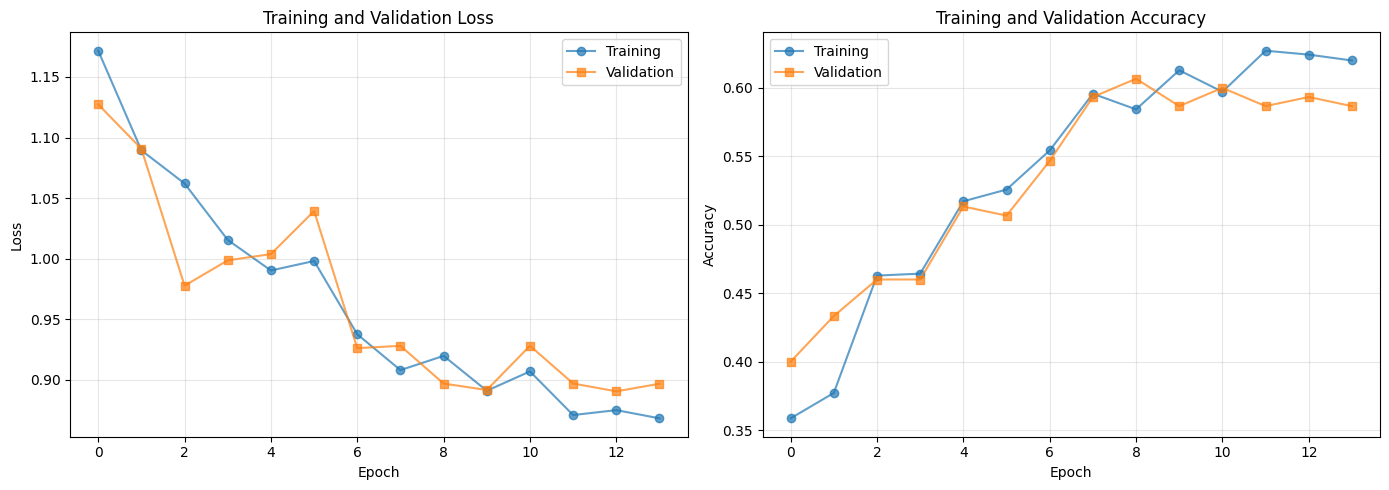


Evaluación en Test Set...


Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 17.98it/s]

Test Loss: 0.8757
Test Accuracy: 62.00%

Muestrando predicciones...


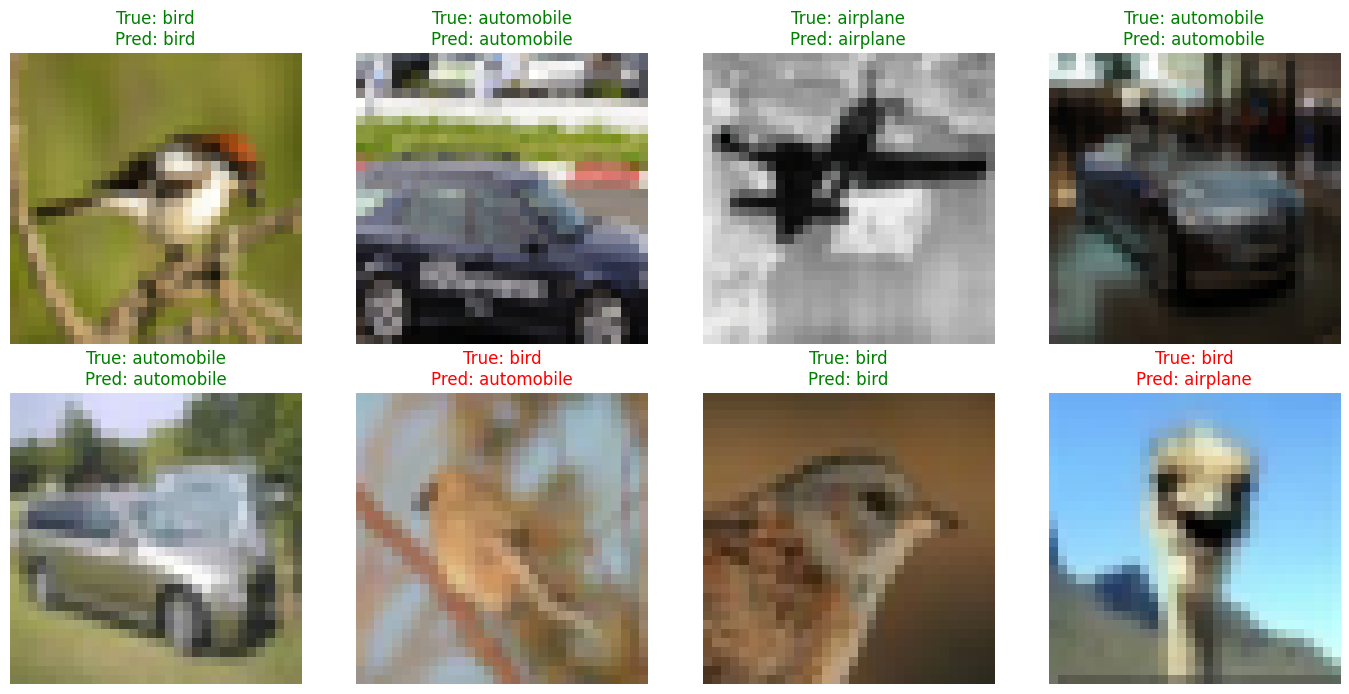

In [57]:
# Graficar curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida
axes[0].plot(history['train_loss'], label='Training', marker='o', alpha=0.7)
axes[0].plot(history['val_loss'], label='Validation', marker='s', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precisión
axes[1].plot(history['train_acc'], label='Training', marker='o', alpha=0.7)
axes[1].plot(history['val_acc'], label='Validation', marker='s', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluación en test set
print("\nEvaluación en Test Set...")
test_loss, test_acc = evaluate(vit_model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {100*test_acc:.2f}%")

# Predicciones en muestra
print("\nMuestrando predicciones...")
batch_images, batch_labels = next(iter(test_loader))
batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)

with torch.no_grad():
    outputs = vit_model(batch_images)
    _, predictions = torch.max(outputs, 1)

# Visualizar
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
classes = selected_classes

for i, ax in enumerate(axes.flat):
    img = batch_images[i].cpu()
    # Denormalizar
    img = img * torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1) + \
          torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    img = torch.clamp(img, 0, 1).permute(1, 2, 0)
    
    ax.imshow(img)
    true_label = classes[batch_labels[i]]
    pred_label = classes[predictions[i]]
    
    color = 'green' if predictions[i] == batch_labels[i] else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Preguntas Clave - Respuestas Esperadas

### 1. ¿Cómo conviertes una imagen en una secuencia de tokens?

**Respuesta:** Dividiendo la imagen en patches no superpuestos de tamaño $P \times P$ (ej: 16×16). Cada patch se aplana (flatten) en un vector de dimensión $P^2 \cdot C$ (ej: 768 para RGB). Luego se proyecta linealmente a la dimensión de embedding del modelo.

### 2. ¿Qué representa cada patch?

**Respuesta:** Cada patch es una región rectangular de la imagen que contiene píxeles adyacentes. Por ejemplo, en una imagen de 224×224 con patches de 16×16, hay 196 patches que cubren toda la imagen sin sobreposición. Cada patch captura información local de colores y texturas.

### 3. ¿Qué hace la proyección lineal de patches?

**Respuesta:** Transforma los valores de píxeles (valores brutos 0-255 o normalizados) en un espacio de embedding continuo de dimensión `embed_dim`. Esta proyección es aprendible durante el entrenamiento y permite al modelo encontrar representaciones que sean útiles para la clasificación.

### 4. ¿Para qué sirve el token [class]?

**Respuesta:** Es un token especial aprendible que se agrega al inicio de la secuencia. Después de procesar por los bloques transformer, solo la salida de este token se usa para predicción de clase. Funciona como un "representante global" que integra información de todos los patches.

### 5. ¿Qué aporta el embedding posicional?

**Respuesta:** Proporciona información espacial sobre la posición de cada patch en la imagen original. Sin él, el modelo no sabría dónde está cada patch. Se usa codificación sinusoidal para que sea diferente para cada posición pero de forma suave.

### 6. ¿Qué ocurre si cambias el tamaño del patch?

**Respuesta:**
- Patches **más pequeños** (4×4): Más tokens, más atención pero más costoso computacionalmente, potencialmente más captura de detalles
- Patches **más grandes** (16×16): Menos tokens, menos costoso, pero puede perder detalles fino

### 7. ¿Qué diferencia hubo entre tus variantes?

**Respuesta:**
### 8. ¿Qué errores de clasificación observaste?

**Respuesta:**
- El modelo aún confunde clases visualmente similares.

### 9. ¿Por qué ViT usa atención sobre patches y no convoluciones tradicionales?

**Respuesta:**
- **Atención:** Permite relaciones globales entre patches distantes. Cada patch puede atender a todos los demás.
- **Convoluciones:** Conexiones locales, receptive field limitado a vecinos cercanos.
- **ViT:** Mejor para capturar relaciones globales y más fácil de escalar.

### 10. ¿Cómo se relaciona tu implementación con el Learner-Vit-Workbook?

**Respuesta:** El notebook implementa el flujo exacto descrito en el excel: Imagen → Patches (IM2COL) → Proyección lineal → Token [class] + Positional Encoding → Transformer blocks → Clasificación. Cada paso corresponde a una sección del workbook.